In [5]:
#----------------------------------------
# IMPORTS
#----------------------------------------

import numpy as np
import pathlib, os
import pyklip.klip as klip
from LBT_klip import LBT
import pyklip.parallelized as parallelized
from astropy.io import fits
import matplotlib.pyplot as plt
print("imports loaded")

imports loaded


In [6]:
obj = 'procyon'
injected_dir =  "/media/vivekvijayakumar/LargeSSD/Procyon_4/injected"

reduced_data = np.load(obj+"_NOMIC_aligned.npz", allow_pickle=True)
array_shape = (300,300)
file_size = reduced_data["arr_4"]
reffit = reduced_data["arr_7"]

binned_data = np.load(obj+"_NOMIC_binned_evaluated.npz", allow_pickle=True)
binned_files = binned_data["arr_9"]
binned_chops = binned_data["arr_10"]
binned_angles = binned_data["arr_11"]

injected_files = np.asarray(sorted(list(pathlib.Path(str(injected_dir)).rglob('*.fits'))))

origin = [array_shape[0]/2 - 0.5, array_shape[0]/2 - 0.5]

root_dir = os.path.dirname(os.path.dirname(binned_files[0]))
klipped_dir=os.path.join(root_dir,'klipped')
if not os.path.exists(klipped_dir):
    os.makedirs(klipped_dir)
print("file loaded")

file loaded


571


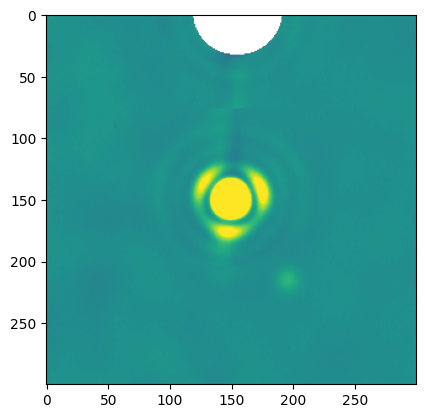

In [7]:
print(len(injected_files))
hdul = fits.open(injected_files[100])
plt.imshow(hdul[0].data, vmin=-0.01, vmax=0.01)
plt.show()

In [8]:

dataset = LBT(injected_files, PAs=binned_angles,\
                    framew=array_shape[0], frameh=array_shape[1], origin=origin)


parallelized.klip_dataset(dataset, outputdir=klipped_dir, 
                          annuli=1, subsections=1, movement=2, numbasis=[10, 20,50],
                          calibrate_flux=False, mode="ADI")


Begin align and scale images for each wavelength
Wavelength 1.0 with index 0 has finished align and scale. Queuing for KLIP
Total number of tasks for KLIP processing is 1


  0%|          | 0/1 [00:00<?, ?it/s]

Closing threadpool
Derotating Images...
Writing Images to directory /media/vivekvijayakumar/LargeSSD/Procyon_4/klipped
wavelength collapsing reduced data of shape (b, N, wv, y, x):(3, 571, 1, 300, 300)


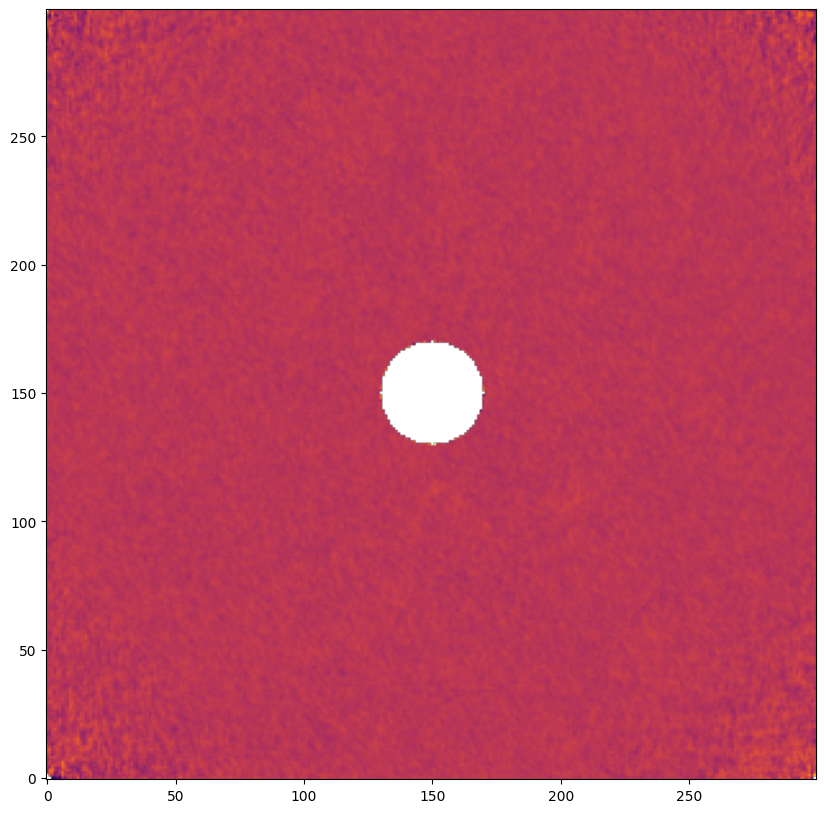

In [9]:
klipped = fits.open(os.path.join(klipped_dir, "-KLmodes-all.fits"))

plt.figure(figsize=(10,10))
plt.imshow(klipped[0].data[1], cmap="inferno", origin="lower",  vmin=-0.0001, vmax=0.0001)
plt.show()